<a href="https://colab.research.google.com/github/kavyad4/beyond-correlation-food-insecurity/blob/main/Beyond_Correlation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Cell1
!pip install -q xgboost lightgbm shap
print("Done installing packages.")

Done installing packages.


In [ ]:
#Cell2
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import xgboost as xgb
import lightgbm as lgb
import shap

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Important column names
TARGET = "FAO_Avg Population in Severe Food Insecurity (thousands)"
AREA_COL = "Area"
YEAR_COL = "Time period"

# We will forecast these years
TEST_START_YEAR = 2020
TEST_END_YEAR = 2021

print("Imports complete.")

Imports complete.


In [ ]:
# Cell 3
import pandas as pd
from google.colab import files

uploaded = files.upload()

csv_files = [
    name
    for name in uploaded.keys()
    if name.lower().endswith(".csv")
]

if len(csv_files) == 0:
    raise FileNotFoundError(
        "Please upload research_base_dataset.csv"
    )

research_files = [
    name
    for name in csv_files
    if name.lower().startswith("research_base_dataset")
]

if research_files:
    csv_name = research_files[0]
else:
    csv_name = csv_files[0]

print("Using dataset:", csv_name)

df = pd.read_csv(csv_name)

required_cols = {
    AREA_COL,
    YEAR_COL,
    TARGET
}

missing_cols = required_cols - set(df.columns)

if missing_cols:
    raise ValueError(
        f"Missing required columns: {sorted(missing_cols)}"
    )

df[YEAR_COL] = pd.to_numeric(
    df[YEAR_COL],
    errors="coerce"
)

df[TARGET] = pd.to_numeric(
    df[TARGET],
    errors="coerce"
)

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Countries/Areas: {df[AREA_COL].nunique()}")

print(
    f"Missing {YEAR_COL} values:",
    df[YEAR_COL].isna().sum()
)

print(
    f"Missing/non-exact {TARGET} values:",
    df[TARGET].isna().sum()
)

print(
    f"Years: "
    f"{df[YEAR_COL].min():.0f}–"
    f"{df[YEAR_COL].max():.0f}"
)

duplicates = df.duplicated(
    subset=[AREA_COL, YEAR_COL]
).sum()

print(
    f"Duplicate Area-Year rows: {duplicates}"
)

df.head(3)

Saving research_base_dataset (1).csv to research_base_dataset (1).csv
Using dataset: research_base_dataset (1).csv
Rows: 2167
Columns: 24
Countries/Areas: 217
Missing Time period values: 0
Missing/non-exact FAO_Avg Population in Severe Food Insecurity (thousands) values: 1557
Years: 2013–2022
Duplicate Area-Year rows: 0


,Area,Time period,FAO_Avg Population in Severe Food Insecurity (thousands),Level of water stress: freshwater withdrawal as a proportion of available freshwater resources,Access to electricity (% of population),CO2 emissions (metric tons per capita),"Agriculture, forestry, and fishing, value added (% of GDP)",Renewable electricity output (% of total electricity output),Political Stability and Absence of Violence/Terrorism: Estimate,Adjusted savings: energy depletion (% of GNI),...,"Water productivity, total (constant 2015 US$ GDP per cubic meter of total freshwater withdrawal)",CPIA policy and institutions for environmental sustainability rating (1=low to 6=high),Nitrous oxide emissions in energy sector (thousand metric tons of CO2 equivalent),Trade (% of GDP),"Access to electricity, rural (% of rural population)",Alternative and nuclear energy (% of total energy use),CPIA business regulatory environment rating (1=low to 6=high),"Electricity production from oil, gas and coal sources (% of total)","Annual freshwater withdrawals, total (% of internal resources)",final_sentiment_score
0,Afghanistan,2013.0,NaN,54.757019,68.040878,0.298088,22.810663,78.636408,-2.519349,0.121907,...,0.905249,2.5,0.0,NaN,60.239198,NaN,2.5,NaN,43.015907,NaN
1,Afghanistan,2014.0,NaN,54.757019,89.500000,0.283692,22.137041,85.323549,-2.411068,0.096664,...,0.929913,2.5,0.1,NaN,86.500512,NaN,2.5,NaN,43.015907,NaN
2,Afghanistan,2015.0,4973.2,54.757019,71.500000,0.297972,20.634323,86.050111,-2.562625,0.055987,...,0.943409,2.5,0.0,NaN,64.573354,NaN,2.5,NaN,43.015907,NaN


=== TARGET VARIABLE ===
Min: 100.5
Max: 45,404.8
Mean: 3,332.8
Missing values: 1557


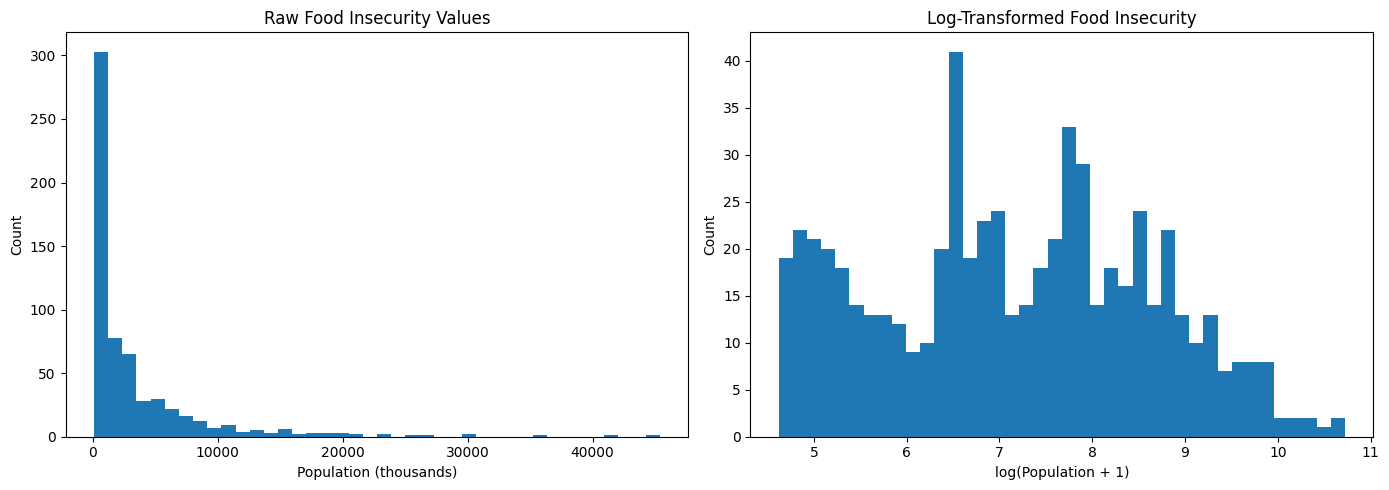

In [ ]:
#Cell4
print("=== TARGET VARIABLE ===")

print(
  f"Min: "
  f"{df[TARGET].min():,.1f}"
)

print(
    f"Max: "
    f"{df[TARGET].max():,.1f}"
)

print(
    f"Mean: "
    f"{df[TARGET].mean():,.1f}"
)

print(
    f"Missing values: "
    f"{df[TARGET].isna().sum()}"
)


if "Sentiment_Category" in df.columns:

    print("\n=== SENTIMENT BREAKDOWN ===")

    print(
        df["Sentiment_Category"]
        .value_counts(dropna=False)
    )


if "ESG_Score" in df.columns:

    print("\n=== ESG SCORE ===")

    print(
        f"Min: "
        f"{df['ESG_Score'].min():.2f}"
    )

    print(
        f"Max: "
        f"{df['ESG_Score'].max():.2f}"
    )

    print(
        f"Mean: "
        f"{df['ESG_Score'].mean():.2f}"
    )


# Log transformation
df["target_log_current"] = np.log1p(
    df[TARGET]
)


# Plot raw vs transformed target
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

axes[0].hist(
    df[TARGET].dropna(),
    bins=40
)

axes[0].set_title(
    "Raw Food Insecurity Values"
)

axes[0].set_xlabel(
    "Population (thousands)"
)

axes[0].set_ylabel(
    "Count"
)


axes[1].hist(
    df["target_log_current"].dropna(),
    bins=40
)

axes[1].set_title(
    "Log-Transformed Food Insecurity"
)

axes[1].set_xlabel(
    "log(Population + 1)"
)

axes[1].set_ylabel(
    "Count"
)

if (df[TARGET].dropna() < 0).any():
    raise ValueError("Target contains negative values; log1p transformation is not appropriate.")

df["target_log_current"] = np.log1p(df[TARGET])

plt.tight_layout()
plt.show()

In [ ]:
#Cell 5
# Sort chronologically within each country
df_sorted = df.sort_values(
    [AREA_COL, YEAR_COL]
).copy()


# Create next year's food insecurity target
df_sorted["target_next_raw"] = (
    df_sorted
    .groupby(AREA_COL)[TARGET]
    .shift(-1)
)


df_sorted["target_next_log"] = np.log1p(
    df_sorted["target_next_raw"]
)


# The year we are predicting
df_sorted["target_year"] = (
    df_sorted[YEAR_COL] + 1
)


# Check that the next observation is really the next year
next_observed_year = (
    df_sorted
    .groupby(AREA_COL)[YEAR_COL]
    .shift(-1)
)


df_sorted["is_consecutive_target"] = (
    next_observed_year
    == df_sorted[YEAR_COL] + 1
)


# Keep only rows where the next year actually exists
forecast_df = df_sorted[
    df_sorted["is_consecutive_target"]
    &
    df_sorted["target_next_log"].notna()
].copy()


print(
    f"Original rows: "
    f"{len(df_sorted)}"
)

print(
    f"Valid one-year-ahead observations: "
    f"{len(forecast_df)}"
)

print(
    f"Target years: "
    f"{forecast_df['target_year'].min():.0f}"
    f"–"
    f"{forecast_df['target_year'].max():.0f}"
)

Original rows: 2167
Valid one-year-ahead observations: 610
Target years: 2015–2021


In [ ]:
# Cell 6
# Variables where historical values may be useful
requested_lag_cols = [

    "ESG_Score",

    "final_sentiment_score",

    "Renewable energy consumption (% of total final energy consumption)",

    "Political Stability and Absence of Violence/Terrorism: Estimate"
]


# Only use columns that actually exist
lag_cols = [

    col

    for col in requested_lag_cols

    if col in df_sorted.columns
]


# Create 1-year and 2-year lag features
for col in lag_cols:

    df_sorted[
        f"{col}_lag1"
    ] = (

        df_sorted

        .groupby(AREA_COL)[col]

        .shift(1)

    )


    df_sorted[
        f"{col}_lag2"
    ] = (

        df_sorted

        .groupby(AREA_COL)[col]

        .shift(2)

    )


# ESG trend
if "ESG_Score" in df_sorted.columns:

    df_sorted[
        "ESG_trend"
    ] = (

        df_sorted

        .groupby(AREA_COL)["ESG_Score"]

        .diff()

    )


# Recreate forecast data after lag features were added
next_observed_year = (

    df_sorted

    .groupby(AREA_COL)[YEAR_COL]

    .shift(-1)

)


df_sorted["is_consecutive_target"] = (

    next_observed_year

    == df_sorted[YEAR_COL] + 1

)


forecast_df = df_sorted[

    df_sorted["is_consecutive_target"]

    &

    df_sorted["target_next_log"].notna()

].copy()


print("Lag features created:")

for col in forecast_df.columns:

    if "_lag" in col or col == "ESG_trend":

        print(" -", col)

Lag features created:
 - final_sentiment_score_lag1
 - final_sentiment_score_lag2
 - Renewable energy consumption (% of total final energy consumption)_lag1
 - Renewable energy consumption (% of total final energy consumption)_lag2
 - Political Stability and Absence of Violence/Terrorism: Estimate_lag1
 - Political Stability and Absence of Violence/Terrorism: Estimate_lag2


In [ ]:
#Cell7
# Columns that should NOT be predictors
exclude_cols = {

    AREA_COL,

    YEAR_COL,

    TARGET,

    "target_log_current",

    "target_next_raw",

    "target_next_log",

    "target_year",

    "is_consecutive_target",

    "Sentiment_Category"
}


# Automatically select numeric features only
numeric_cols = (

    forecast_df

    .select_dtypes(
        include=[np.number]
    )

    .columns

    .tolist()
)


feature_cols = [

    col

    for col in numeric_cols

    if col not in exclude_cols
]


print(
    f"Number of features: "
    f"{len(feature_cols)}"
)


print("\nFeatures:")

for i, feature in enumerate(
    feature_cols,
    start=1
):

    print(
        f"{i}. {feature}"
    )


# Only evaluate through 2022
model_df = forecast_df[

    forecast_df[
        "target_year"
    ] <= TEST_END_YEAR

].copy()


# Training target years:
# everything before 2020
train_mask = (

    model_df[
        "target_year"
    ] < TEST_START_YEAR

)


# Test target years:
# 2020 through 2022
test_mask = (

    model_df[
        "target_year"
    ]

    .between(
        TEST_START_YEAR,
        TEST_END_YEAR
    )

)


train_df = (

    model_df

    .loc[train_mask]

    .copy()

)


test_df = (

    model_df

    .loc[test_mask]

    .copy()

)


print("\n=== TEMPORAL SPLIT ===")


print(
    f"Training rows: "
    f"{len(train_df)}"
)


print(
    f"Training target years: "
    f"{train_df['target_year'].min():.0f}"
    f"–"
    f"{train_df['target_year'].max():.0f}"
)


print(
    f"Testing rows: "
    f"{len(test_df)}"
)


print(
    f"Testing target years: "
    f"{test_df['target_year'].min():.0f}"
    f"–"
    f"{test_df['target_year'].max():.0f}"
)

Number of features: 27

Features:
1. Level of water stress: freshwater withdrawal as a proportion of available freshwater resources
2. Access to electricity (% of population)
3. CO2 emissions (metric tons per capita)
4. Agriculture, forestry, and fishing, value added (% of GDP)
5. Renewable electricity output (% of total electricity output)
6. Political Stability and Absence of Violence/Terrorism: Estimate
7. Adjusted savings: energy depletion (% of GNI)
8. CO2 emissions from liquid fuel consumption (% of total)
9. Electricity production from renewable sources, excluding hydroelectric (% of total)
10. GDP growth (annual %)
11. Renewable energy consumption (% of total final energy consumption)
12. Water productivity, total (constant 2015 US$ GDP per cubic meter of total freshwater withdrawal)
13. CPIA policy and institutions for environmental sustainability rating (1=low to 6=high)
14. Nitrous oxide emissions in energy sector (thousand metric tons of CO2 equivalent)
15. Trade (% of GDP)

In [ ]:
#Cell8
# Separate predictors and target
X_train_raw = train_df[
    feature_cols
].copy()


X_test_raw = test_df[
    feature_cols
].copy()


y_train = train_df[
    "target_next_log"
].values


y_test = test_df[
    "target_next_log"
].values


# Missing-value imputation
# Fit ONLY on training data
imputer = SimpleImputer(
    strategy="median"
)


X_train_imputed = imputer.fit_transform(
    X_train_raw
)


X_test_imputed = imputer.transform(
    X_test_raw
)


# Standardization
# Fit ONLY on training data
scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(
    X_train_imputed
)


X_test_scaled = scaler.transform(
    X_test_imputed
)


print(
    "Training matrix:",
    X_train_scaled.shape
)


print(
    "Testing matrix:",
    X_test_scaled.shape
)

Training matrix: (405, 27)
Testing matrix: (205, 27)


In [ ]:
#Cell9
models = {

    "Ridge Regression (Baseline)":

        Ridge(
            alpha=1.0
        ),


    "Random Forest":

        RandomForestRegressor(

            n_estimators=300,

            random_state=SEED,

            n_jobs=-1

        ),


    "Gradient Boosting":

        GradientBoostingRegressor(

            n_estimators=300,

            random_state=SEED

        ),


    "XGBoost":

        xgb.XGBRegressor(

            n_estimators=300,

            random_state=SEED,

            verbosity=0,

            objective="reg:squarederror"

        ),


    "LightGBM":

        lgb.LGBMRegressor(

            n_estimators=300,

            random_state=SEED,

            verbose=-1

        )

}


results = {}


print(

    f"{'Model':<35}"

    f"{'RMSE(log)':>12}"

    f"{'MAE(log)':>12}"

    f"{'R²':>10}"

    f"{'RMSE(raw)':>14}"

    f"{'MAE(raw)':>14}"

)


print("-" * 97)


for name, model in models.items():


    # Train
    model.fit(

        X_train_scaled,

        y_train

    )


    # Predict
    preds_log = model.predict(

        X_test_scaled

    )


    # Metrics on log scale
    rmse_log = np.sqrt(

        mean_squared_error(

            y_test,

            preds_log

        )

    )


    mae_log = mean_absolute_error(

        y_test,

        preds_log

    )


    r2 = r2_score(

        y_test,

        preds_log

    )


    # Convert predictions back to original units
    actual_raw = np.expm1(

        y_test

    )


    preds_raw = np.expm1(

        preds_log

    )


    # Prevent negative population predictions
    preds_raw = np.clip(

        preds_raw,

        0,

        None

    )


    rmse_raw = np.sqrt(

        mean_squared_error(

            actual_raw,

            preds_raw

        )

    )


    mae_raw = mean_absolute_error(

        actual_raw,

        preds_raw

    )


    results[name] = {

        "model": model,

        "preds_log": preds_log,

        "rmse_log": rmse_log,

        "mae_log": mae_log,

        "r2": r2,

        "rmse_raw": rmse_raw,

        "mae_raw": mae_raw

    }


    print(

        f"{name:<35}"

        f"{rmse_log:>12.4f}"

        f"{mae_log:>12.4f}"

        f"{r2:>10.4f}"

        f"{rmse_raw:>14.2f}"

        f"{mae_raw:>14.2f}"

    )


# Select best model
best_model_name = max(

    results,

    key=lambda name:

        results[name]["r2"]

)


print(

    f"\n✅ Best classical model: "

    f"{best_model_name}"

)


print(

    f"R² = "

    f"{results[best_model_name]['r2']:.4f}"

)

Model                                 RMSE(log)    MAE(log)        R²     RMSE(raw)      MAE(raw)
-------------------------------------------------------------------------------------------------
Ridge Regression (Baseline)              1.2629      0.8718    0.3244       5499.17       2534.34
Random Forest                            0.5663      0.4172    0.8642       3578.39       1477.37
Gradient Boosting                        0.5735      0.4265    0.8607       3709.66       1501.33
XGBoost                                  0.5429      0.4013    0.8752       3204.49       1316.87
LightGBM                                 0.5543      0.4045    0.8699       3467.81       1378.14

✅ Best classical model: XGBoost
R² = 0.8752


In [ ]:
# Revised Cell 10 — Correlation Analysis

from scipy.stats import pearsonr
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
import pandas as pd
import numpy as np


print("=== TRAINING-DATA CORRELATIONS ===\n")

correlations = []


for col in feature_cols:

    # Keep rows with valid country, feature and target
    temp = train_df[
        [
            AREA_COL,
            col,
            "target_next_log"
        ]
    ].dropna().copy()

    # Need at least 3 observations
    if len(temp) < 3:
        continue

    # Skip constant features
    if temp[col].nunique() <= 1:
        continue

    # Need at least two countries for clustered errors
    if temp[AREA_COL].nunique() < 2:
        continue

    # Pearson correlation
    r, p_pearson = pearsonr(
        temp[col],
        temp["target_next_log"]
    )

    # Country-clustered significance test
    X = sm.add_constant(
        temp[[col]],
        has_constant="add"
    )

    cluster_model = sm.OLS(
        temp["target_next_log"],
        X
    ).fit(
        cov_type="cluster",
        cov_kwds={
            "groups": temp[AREA_COL]
        }
    )

    p_cluster = float(
        cluster_model.pvalues.iloc[1]
    )

    correlations.append({
        "Feature": col,
        "r": r,
        "Pearson_p": p_pearson,
        "Cluster_p": p_cluster
    })


# Convert to DataFrame
correlation_df = pd.DataFrame(
    correlations
)


if not correlation_df.empty:

    # Benjamini-Hochberg FDR correction
    reject, q_values, _, _ = multipletests(
        correlation_df["Cluster_p"],
        alpha=0.05,
        method="fdr_bh"
    )

    correlation_df["FDR_q"] = q_values

    correlation_df["Significance"] = np.where(
        reject,
        "Significant",
        "Not significant"
    )

    # Sort by absolute correlation
    correlation_df["abs_r"] = (
        correlation_df["r"].abs()
    )

    correlation_df = (
        correlation_df
        .sort_values(
            "abs_r",
            ascending=False
        )
        .drop(columns="abs_r")
        .reset_index(drop=True)
    )

    print(
        correlation_df.to_string(
            index=False,
            formatters={
                "r": lambda x: f"{x:.3f}",
                "Pearson_p": lambda x: f"{x:.4g}",
                "Cluster_p": lambda x: f"{x:.4g}",
                "FDR_q": lambda x: f"{x:.4g}"
            }
        )
    )

else:
    print(
        "No valid features available "
        "for correlation analysis."
    )



=== TRAINING-DATA CORRELATIONS ===

                                                                                         Feature      r Pearson_p Cluster_p     FDR_q    Significance
                                 Political Stability and Absence of Violence/Terrorism: Estimate -0.563 3.259e-35 4.519e-12  2.44e-11     Significant
                            Political Stability and Absence of Violence/Terrorism: Estimate_lag1 -0.562 4.701e-35 7.921e-13 5.347e-12     Significant
                            Political Stability and Absence of Violence/Terrorism: Estimate_lag2 -0.560 9.481e-29 2.506e-13 2.256e-12     Significant
                                            Access to electricity, rural (% of rural population) -0.538 3.251e-30 4.608e-11 2.073e-10     Significant
                                                                                Trade (% of GDP) -0.503 1.578e-25 7.354e-09 2.482e-08     Significant
                                                         Access 

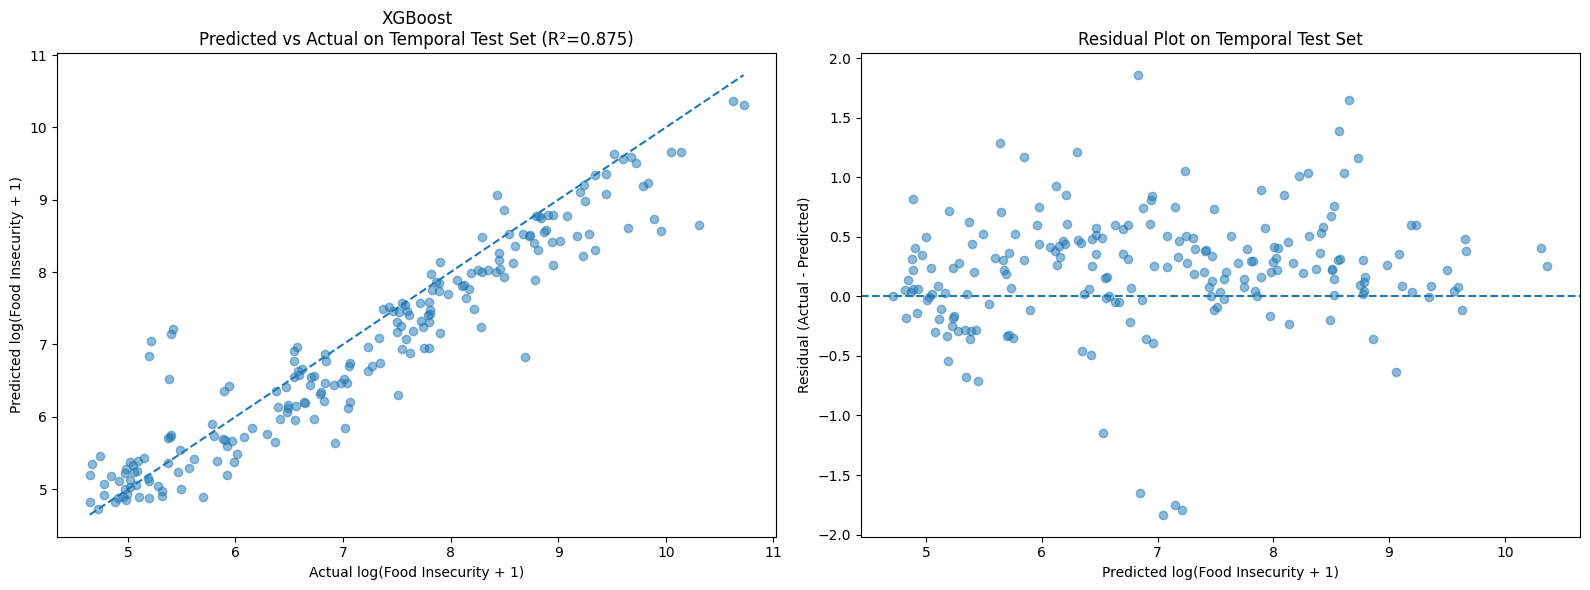

In [ ]:
#Cell 11
best_model = results[
    best_model_name
]["model"]


best_preds = results[
    best_model_name
]["preds_log"]


fig, axes = plt.subplots(

    1,

    2,

    figsize=(16, 6)

)


# Predicted vs Actual
axes[0].scatter(

    y_test,

    best_preds,

    alpha=0.5

)


minimum = min(

    y_test.min(),

    best_preds.min()

)


maximum = max(

    y_test.max(),

    best_preds.max()

)


axes[0].plot(

    [minimum, maximum],

    [minimum, maximum],

    "--"

)
axes[0].set_title(
    f"{best_model_name}\n"
    f"Predicted vs Actual on Temporal Test Set "
    f"(R²={results[best_model_name]['r2']:.3f})"
)




axes[0].set_xlabel(

    "Actual log(Food Insecurity + 1)"

)


axes[0].set_ylabel(

    "Predicted log(Food Insecurity + 1)"

)


# Residual plot
residuals = (

    y_test

    - best_preds

)


axes[1].scatter(

    best_preds,

    residuals,

    alpha=0.5

)


axes[1].axhline(

    0,

    linestyle="--"

)





axes[1].set_title(
    "Residual Plot on Temporal Test Set"
)

axes[1].set_xlabel(
    "Predicted log(Food Insecurity + 1)"
)




axes[1].set_ylabel(

    "Residual (Actual - Predicted)"

)


plt.tight_layout()


plt.savefig(

    "predictions.png",

    dpi=150,

    bbox_inches="tight"

)


plt.show()

In [ ]:
# Cell 12

tree_model_names = [
    "Random Forest",
    "Gradient Boosting",
    "XGBoost",
    "LightGBM"
]


best_tree_name = max(
    tree_model_names,
    key=lambda name:
        results[name]["r2"]
)


best_tree_model = results[
    best_tree_name
]["model"]


print(
    f"Best-performing classical model "
    f"on temporal test set: "
    f"{best_model_name}"
)


print(
    f"R²: "
    f"{results[best_model_name]['r2']:.4f}"
)


print(
    f"\nBest-performing tree-based model "
    f"on temporal test set for SHAP: "
    f"{best_tree_name}"
)


print(
    f"R²: "
    f"{results[best_tree_name]['r2']:.4f}"
)

Best-performing classical model on temporal test set: XGBoost
R²: 0.8752

Best-performing tree-based model on temporal test set for SHAP: XGBoost
R²: 0.8752


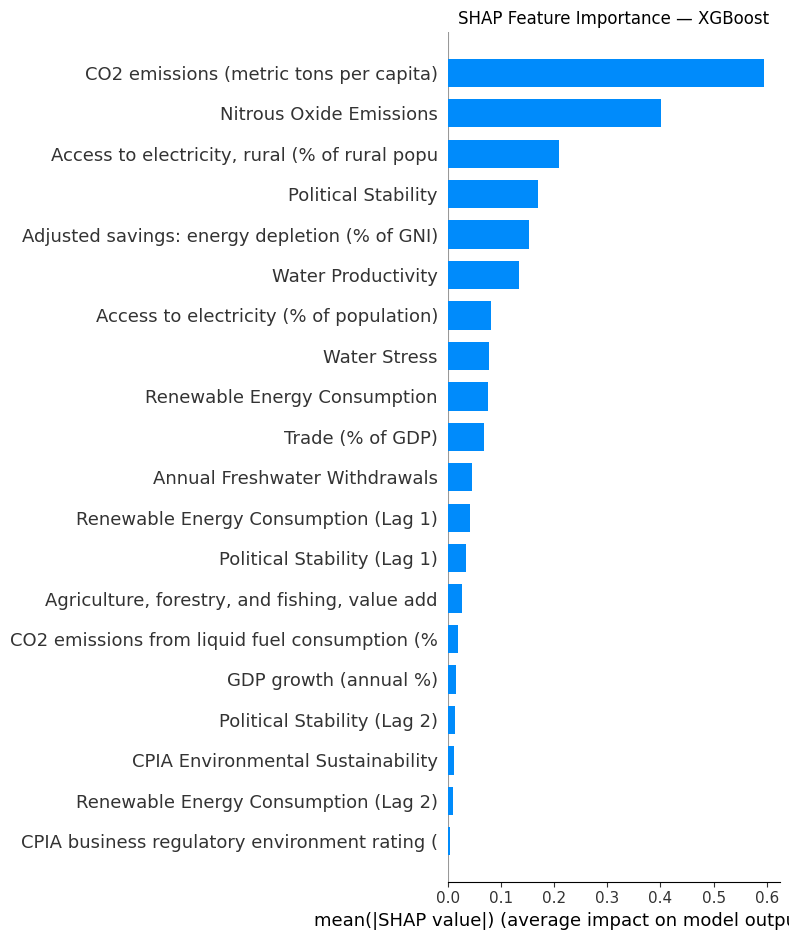

In [ ]:
# Cell 13

# Create SHAP explainer
explainer = shap.TreeExplainer(
    best_tree_model
)


# Calculate SHAP values
shap_values = explainer.shap_values(
    X_test_scaled
)


# Create readable and unique feature names
name_map = {

    "Political Stability and Absence of Violence/Terrorism: Estimate":
        "Political Stability",

    "Political Stability and Absence of Violence/Terrorism: Estimate_lag1":
        "Political Stability (Lag 1)",

    "Political Stability and Absence of Violence/Terrorism: Estimate_lag2":
        "Political Stability (Lag 2)",

    "Renewable energy consumption (% of total final energy consumption)":
        "Renewable Energy Consumption",

    "Renewable energy consumption (% of total final energy consumption)_lag1":
        "Renewable Energy Consumption (Lag 1)",

    "Renewable energy consumption (% of total final energy consumption)_lag2":
        "Renewable Energy Consumption (Lag 2)",

    "Nitrous oxide emissions in energy sector (thousand metric tons of CO2 equivalent)":
        "Nitrous Oxide Emissions",

    "Annual freshwater withdrawals, total (% of internal resources)":
        "Annual Freshwater Withdrawals",

    "Water productivity, total (constant 2015 US$ GDP per cubic meter of total freshwater withdrawal)":
        "Water Productivity",

    "Level of water stress: freshwater withdrawal as a proportion of available freshwater resources":
        "Water Stress",

    "CPIA policy and institutions for environmental sustainability rating (1=low to 6=high)":
        "CPIA Environmental Sustainability"
}


short_names = [
    name_map.get(
        feature,
        feature[:45]
    )
    for feature in feature_cols
]


# SHAP importance bar plot
plt.figure(
    figsize=(12, 9)
)


shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=short_names,
    plot_type="bar",
    show=False
)


plt.title(
    f"SHAP Feature Importance — {best_tree_name}"
)


plt.tight_layout()


plt.savefig(
    "shap_importance.png",
    dpi=150,
    bbox_inches="tight"
)


plt.show()

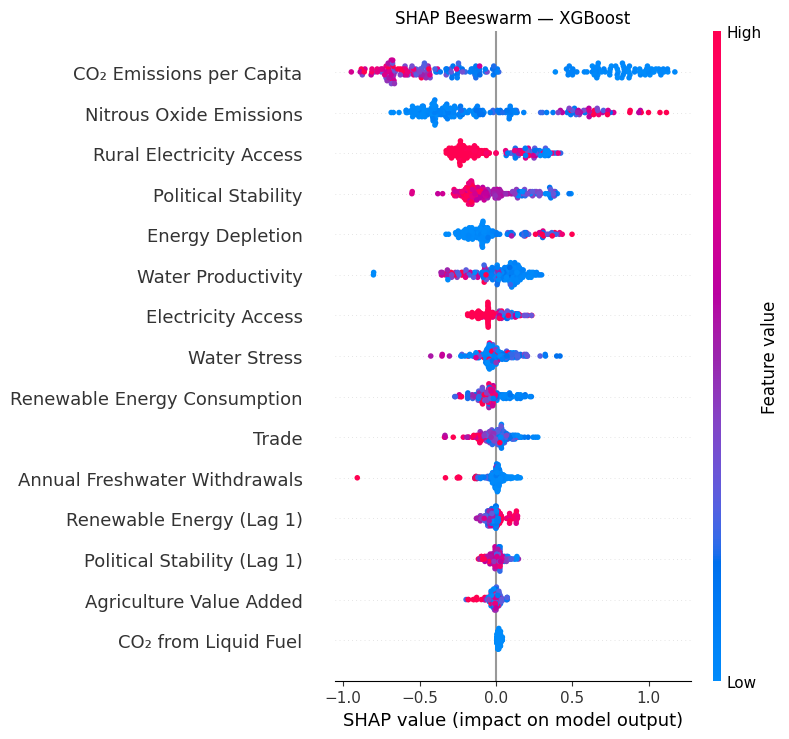

In [ ]:
# Cell 14

# Create short, readable, and unique feature names
name_map = {

    "ESG_Score":
        "ESG Score",

    "ESG_Score_lag1":
        "ESG Score (Lag 1)",

    "ESG_Score_lag2":
        "ESG Score (Lag 2)",

    "ESG_trend":
        "ESG Trend",

    "final_sentiment_score":
        "Sentiment Score",

    "final_sentiment_score_lag1":
        "Sentiment Score (Lag 1)",

    "final_sentiment_score_lag2":
        "Sentiment Score (Lag 2)",

    "Political Stability and Absence of Violence/Terrorism: Estimate":
        "Political Stability",

    "Political Stability and Absence of Violence/Terrorism: Estimate_lag1":
        "Political Stability (Lag 1)",

    "Political Stability and Absence of Violence/Terrorism: Estimate_lag2":
        "Political Stability (Lag 2)",

    "Renewable energy consumption (% of total final energy consumption)":
        "Renewable Energy Consumption",

    "Renewable energy consumption (% of total final energy consumption)_lag1":
        "Renewable Energy (Lag 1)",

    "Renewable energy consumption (% of total final energy consumption)_lag2":
        "Renewable Energy (Lag 2)",

    "Nitrous oxide emissions in energy sector (thousand metric tons of CO2 equivalent)":
        "Nitrous Oxide Emissions",

    "Annual freshwater withdrawals, total (% of internal resources)":
        "Annual Freshwater Withdrawals",

    "Water productivity, total (constant 2015 US$ GDP per cubic meter of total freshwater withdrawal)":
        "Water Productivity",

    "Level of water stress: freshwater withdrawal as a proportion of available freshwater resources":
        "Water Stress",

    "CPIA policy and institutions for environmental sustainability rating (1=low to 6=high)":
        "CPIA Environmental Sustainability",

    "CPIA business regulatory environment rating (1=low to 6=high)":
        "CPIA Business Regulation",

    "Agriculture, forestry, and fishing, value added (% of GDP)":
        "Agriculture Value Added",

    "CO2 emissions (metric tons per capita)":
        "CO₂ Emissions per Capita",

    "CO2 emissions from liquid fuel consumption (% of total)":
        "CO₂ from Liquid Fuel",

    "Adjusted savings: energy depletion (% of GNI)":
        "Energy Depletion",

    "Renewable electricity output (% of total electricity output)":
        "Renewable Electricity Output",

    "Electricity production from renewable sources, excluding hydroelectric (% of total)":
        "Non-Hydro Renewable Electricity",

    "Electricity production from oil, gas and coal sources (% of total)":
        "Fossil-Fuel Electricity",

    "Access to electricity (% of population)":
        "Electricity Access",

    "Access to electricity, rural (% of rural population)":
        "Rural Electricity Access",

    "Alternative and nuclear energy (% of total energy use)":
        "Alternative & Nuclear Energy",

    "Trade (% of GDP)":
        "Trade",

    "GDP growth (annual %)":
        "GDP Growth"
}


# Apply readable names
short_names = [

    name_map.get(
        feature,
        feature
    )

    for feature in feature_cols
]


# Create SHAP beeswarm plot
plt.figure(

    figsize=(12, 9)

)


shap.summary_plot(

    shap_values,

    X_test_scaled,

    feature_names=short_names,

    max_display=15,

    show=False

)


plt.title(

    f"SHAP Beeswarm — {best_tree_name}"

)


plt.tight_layout()


# Save figure
plt.savefig(

    "shap_beeswarm.png",

    dpi=150,

    bbox_inches="tight"

)


plt.show()

In [ ]:
#Cell15
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (

    LSTM,

    Dense,

    Dropout,

    Input

)

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import EarlyStopping


tf.random.set_seed(SEED)


# Variables for LSTM
requested_lstm_features = [

    "ESG_Score",

    "Political Stability and Absence of Violence/Terrorism: Estimate",

    "Renewable energy consumption (% of total final energy consumption)",

    "CO2 emissions (metric tons per capita)",

    "Water productivity, total (constant 2015 US$ GDP per cubic meter of total freshwater withdrawal)",

    "Nitrous oxide emissions in energy sector (thousand metric tons of CO2 equivalent)"

]


# Only use features available in dataset
lstm_features = [

    feature

    for feature in requested_lstm_features

    if feature in df_sorted.columns

]


print(

    "LSTM features:"

)


for feature in lstm_features:

    print(

        " -",

        feature

    )


SEQUENCE_LEN = 3


def build_sequences(

    dataframe,

    features,

    target,

    sequence_length

):

    X = []

    y = []

    countries = []

    target_years = []


    for country in dataframe[AREA_COL].unique():


        country_df = (

            dataframe[

                dataframe[AREA_COL]

                == country

            ]

            .sort_values(

                YEAR_COL

            )

            .reset_index(

                drop=True

            )

        )


        for i in range(

            sequence_length,

            len(country_df)

        ):


            sequence_df = country_df.iloc[

                i - sequence_length:

                i

            ]


            target_row = country_df.iloc[i]


            years = sequence_df[

                YEAR_COL

            ].values


            target_year = target_row[

                YEAR_COL

            ]


            # Ensure sequence is consecutive:
            # e.g. 2017, 2018, 2019 -> predict 2020
            expected_years = np.arange(

                target_year

                - sequence_length,

                target_year

            )


            if not np.array_equal(

                years,

                expected_years

            ):

                continue


            if pd.isna(

                target_row[target]

            ):

                continue


            X.append(

                sequence_df[

                    features

                ].values

            )


            y.append(

                np.log1p(

                    target_row[target]

                )

            )


            countries.append(

                country

            )


            target_years.append(

                target_year

            )


    return (

        np.array(X),

        np.array(y),

        np.array(countries),

        np.array(target_years)

    )


X_seq_raw, y_seq, seq_countries, seq_target_years = (

    build_sequences(

        df_sorted,

        lstm_features,

        TARGET,

        SEQUENCE_LEN

    )

)


print(

    "Sequence shape:",

    X_seq_raw.shape

)


print(

    "Target shape:",

    y_seq.shape

)

LSTM features:
 - Political Stability and Absence of Violence/Terrorism: Estimate
 - Renewable energy consumption (% of total final energy consumption)
 - CO2 emissions (metric tons per capita)
 - Water productivity, total (constant 2015 US$ GDP per cubic meter of total freshwater withdrawal)
 - Nitrous oxide emissions in energy sector (thousand metric tons of CO2 equivalent)
Sequence shape: (537, 3, 5)
Target shape: (537,)


In [ ]:
# Cell 16

# Temporal split based on TARGET year
lstm_train_mask = (
    seq_target_years
    < TEST_START_YEAR
)

lstm_test_mask = (
    (seq_target_years >= TEST_START_YEAR)
    &
    (seq_target_years <= TEST_END_YEAR)
)


# Identify final training year for validation
training_target_years = seq_target_years[
    lstm_train_mask
]

validation_year = training_target_years.max()


# Create sub-training and validation masks
subtrain_mask_full = (
    seq_target_years
    < validation_year
)

validation_mask_full = (
    seq_target_years
    == validation_year
)


# Raw sub-training data
X_lstm_subtrain_raw = X_seq_raw[
    subtrain_mask_full
]

y_lstm_subtrain = y_seq[
    subtrain_mask_full
]


# Raw validation data
X_lstm_validation_raw = X_seq_raw[
    validation_mask_full
]

y_lstm_validation = y_seq[
    validation_mask_full
]


# Raw test data
X_lstm_test_raw = X_seq_raw[
    lstm_test_mask
]

y_lstm_test = y_seq[
    lstm_test_mask
]


lstm_test_countries = seq_countries[
    lstm_test_mask
]

lstm_test_years = seq_target_years[
    lstm_test_mask
]


print(
    "Validation target year:",
    validation_year
)

print(
    "Sub-training sequences:",
    len(X_lstm_subtrain_raw)
)

print(
    "Validation sequences:",
    len(X_lstm_validation_raw)
)

print(
    "Testing sequences:",
    len(X_lstm_test_raw)
)


# Number of features
n_features = len(
    lstm_features
)


# Flatten 3D sequences for preprocessing
subtrain_flat = X_lstm_subtrain_raw.reshape(
    -1,
    n_features
)

validation_flat = X_lstm_validation_raw.reshape(
    -1,
    n_features
)

test_flat = X_lstm_test_raw.reshape(
    -1,
    n_features
)


# Missing-value imputation
# Fit ONLY on sub-training data
lstm_imputer = SimpleImputer(
    strategy="median"
)


subtrain_flat = lstm_imputer.fit_transform(
    subtrain_flat
)

validation_flat = lstm_imputer.transform(
    validation_flat
)

test_flat = lstm_imputer.transform(
    test_flat
)


# Scaling
# Fit ONLY on sub-training data
lstm_scaler = MinMaxScaler()


subtrain_flat = lstm_scaler.fit_transform(
    subtrain_flat
)

validation_flat = lstm_scaler.transform(
    validation_flat
)

test_flat = lstm_scaler.transform(
    test_flat
)


# Convert back to 3D LSTM format
X_lstm_subtrain = subtrain_flat.reshape(
    X_lstm_subtrain_raw.shape
)

X_lstm_validation = validation_flat.reshape(
    X_lstm_validation_raw.shape
)

X_lstm_test = test_flat.reshape(
    X_lstm_test_raw.shape
)


print(
    "Final sub-training shape:",
    X_lstm_subtrain.shape
)

print(
    "Final validation shape:",
    X_lstm_validation.shape
)

print(
    "Final testing shape:",
    X_lstm_test.shape
)

Validation target year: 2019.0
Sub-training sequences: 239
Validation sequences: 93
Testing sequences: 205
Final sub-training shape: (239, 3, 5)
Final validation shape: (93, 3, 5)
Final testing shape: (205, 3, 5)


In [ ]:
# Cell 17

# Build LSTM model
lstm_model = Sequential([

    Input(
        shape=(
            SEQUENCE_LEN,
            len(lstm_features)
        )
    ),

    LSTM(
        64,
        return_sequences=True
    ),

    Dropout(
        0.2
    ),

    LSTM(
        32
    ),

    Dropout(
        0.2
    ),

    Dense(
        16,
        activation="relu"
    ),

    Dense(
        1
    )

])


# Compile model
lstm_model.compile(

    optimizer=Adam(
        learning_rate=0.001
    ),

    loss="mse",

    metrics=[
        "mae"
    ]
)


# Early stopping
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=10,

    restore_best_weights=True

)


# Train model
history = lstm_model.fit(

    X_lstm_subtrain,

    y_lstm_subtrain,

    validation_data=(
        X_lstm_validation,
        y_lstm_validation
    ),

    epochs=100,

    batch_size=32,

    callbacks=[
        early_stop
    ],

    shuffle=False,

    verbose=1
)


print(
    "\nLSTM training complete."
)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 52.5491 - mae: 7.1102 - val_loss: 52.2461 - val_mae: 7.0787
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 50.8090 - mae: 6.9861 - val_loss: 50.0046 - val_mae: 6.9174
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 47.9825 - mae: 6.7793 - val_loss: 46.0894 - val_mae: 6.6258
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 42.9813 - mae: 6.3928 - val_loss: 38.4052 - val_mae: 6.0097
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 33.0469 - mae: 5.5349 - val_loss: 24.4124 - val_mae: 4.6708
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 17.5150 - mae: 3.8067 - val_loss: 8.6332 - val_mae: 2.4340
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 5.7649 - mae: 1.9135 - val_loss: 3.4321 - val_mae: 1.5181
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 4.4548 - mae: 1.7084 - val_loss: 4.2098 - val_mae: 1.6929
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 4.5

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step
=== LSTM RESULTS ===
RMSE (log): 1.0193
MAE (log): 0.8344
R²: 0.5599


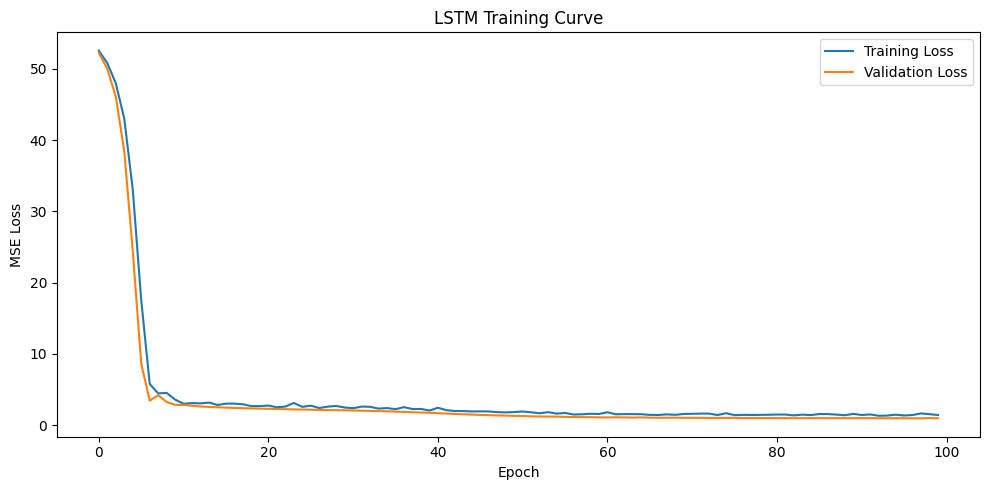

In [ ]:
#Cell18
lstm_preds = (

    lstm_model

    .predict(

        X_lstm_test

    )

    .flatten()

)


lstm_rmse = np.sqrt(

    mean_squared_error(

        y_lstm_test,

        lstm_preds

    )

)


lstm_mae = mean_absolute_error(

    y_lstm_test,

    lstm_preds

)


lstm_r2 = r2_score(

    y_lstm_test,

    lstm_preds

)


print(

    "=== LSTM RESULTS ==="

)


print(

    f"RMSE (log): "

    f"{lstm_rmse:.4f}"

)


print(

    f"MAE (log): "

    f"{lstm_mae:.4f}"

)


print(

    f"R²: "

    f"{lstm_r2:.4f}"

)


# Plot training history
plt.figure(

    figsize=(10, 5)

)


plt.plot(

    history.history["loss"],

    label="Training Loss"

)


plt.plot(

    history.history["val_loss"],

    label="Validation Loss"

)


plt.xlabel(

    "Epoch"

)


plt.ylabel(

    "MSE Loss"

)


plt.title(

    "LSTM Training Curve"

)


plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
#Cell19
# Classical model prediction dataframe
classical_predictions = test_df[

    [

        AREA_COL,

        "target_year",

        "target_next_log"

    ]

].copy()


for model_name in results:


    classical_predictions[

        model_name

    ] = results[

        model_name

    ][

        "preds_log"

    ]


# LSTM prediction dataframe
lstm_predictions_df = pd.DataFrame({

    AREA_COL:

        lstm_test_countries,


    "target_year":

        lstm_test_years,


    "lstm_actual":

        y_lstm_test,


    "LSTM":

        lstm_preds

})


# Merge so every model is compared on the same observations
comparison_df = classical_predictions.merge(

    lstm_predictions_df,

    on=[

        AREA_COL,

        "target_year"

    ],

    how="inner"

)


print(

    f"Common test observations: "

    f"{len(comparison_df)}"

)


final_results = {}


# Evaluate classical models on common observations
for model_name in results:


    actual = comparison_df[

        "target_next_log"

    ]


    predictions = comparison_df[

        model_name

    ]


    final_results[

        model_name

    ] = {

        "rmse":

            np.sqrt(

                mean_squared_error(

                    actual,

                    predictions

                )

            ),


        "mae":

            mean_absolute_error(

                actual,

                predictions

            ),


        "r2":

            r2_score(

                actual,

                predictions

            )

    }


# LSTM on exactly the same observations
final_results[

    "LSTM"

] = {

    "rmse":

        np.sqrt(

            mean_squared_error(

                comparison_df[

                    "target_next_log"

                ],

                comparison_df[

                    "LSTM"

                ]

            )

        ),


    "mae":

        mean_absolute_error(

            comparison_df[

                "target_next_log"

            ],

            comparison_df[

                "LSTM"

            ]

        ),


    "r2":

        r2_score(

            comparison_df[

                "target_next_log"

            ],

            comparison_df[

                "LSTM"

            ]

        )

}


print("\n")

print(

    f"{'Model':<35}"

    f"{'RMSE':>10}"

    f"{'MAE':>10}"

    f"{'R²':>10}"

)


print("-" * 65)


best_final = max(

    final_results,

    key=lambda model:

        final_results[model]["r2"]

)


for model_name, metrics in final_results.items():


    marker = (

        " ✅"

        if model_name == best_final

        else ""

    )


    print(

        f"{model_name:<35}"

        f"{metrics['rmse']:>10.4f}"

        f"{metrics['mae']:>10.4f}"

        f"{metrics['r2']:>10.4f}"

        f"{marker}"

    )


print(

    f"\n✅ Final best model: "

    f"{best_final}"

)


print(

    f"R² = "

    f"{final_results[best_final]['r2']:.4f}"

)

Common test observations: 205


Model                                    RMSE       MAE        R²
-----------------------------------------------------------------
Ridge Regression (Baseline)            1.2629    0.8718    0.3244
Random Forest                          0.5663    0.4172    0.8642
Gradient Boosting                      0.5735    0.4265    0.8607
XGBoost                                0.5429    0.4013    0.8752 ✅
LightGBM                               0.5543    0.4045    0.8699
LSTM                                   1.0193    0.8344    0.5599

✅ Final best model: XGBoost
R² = 0.8752


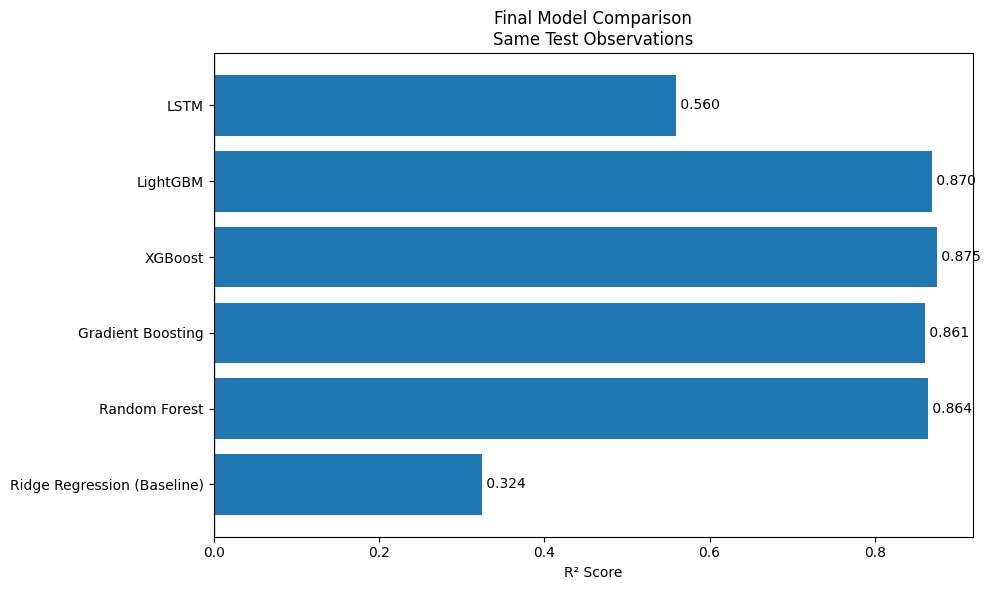

In [ ]:
#Cell20
model_names = list(

    final_results.keys()

)


r2_scores = [

    final_results[

        model

    ][

        "r2"

    ]

    for model in model_names

]


plt.figure(

    figsize=(10, 6)

)


plt.barh(

    model_names,

    r2_scores

)


plt.axvline(

    0,

    linewidth=1

)


plt.xlabel(

    "R² Score"

)


plt.title(

    "Final Model Comparison\n"

    "Same Test Observations"

)


for i, score in enumerate(

    r2_scores

):


    plt.text(

        score,

        i,

        f" {score:.3f}",

        va="center"

    )


plt.tight_layout()


plt.savefig(

    "final_comparison.png",

    dpi=150,

    bbox_inches="tight"

)


plt.show()

In [ ]:
# Final Results Export Cell


# =========================================================
# 1. Save final model comparison results
# =========================================================
import pandas as pd
results_df = pd.DataFrame([

    {
        "Model": model_name,

        "RMSE_log": metrics["rmse"],

        "MAE_log": metrics["mae"],

        "R2": metrics["r2"]
    }

    for model_name, metrics
    in final_results.items()

])


results_df = results_df.sort_values(
    "R2",
    ascending=False
)


results_df.to_csv(
    "model_results.csv",
    index=False
)


# =========================================================
# 2. Save SHAP feature importance results
# =========================================================

shap_array = np.asarray(
    shap_values
)


# Standard regression SHAP output:
# rows = observations
# columns = features
if shap_array.ndim == 2:

    mean_shap = np.abs(
        shap_array
    ).mean(
        axis=0
    )

else:

    # Fallback for alternative SHAP output formats
    mean_shap = np.abs(
        shap_array
    ).mean(
        axis=tuple(
            range(
                shap_array.ndim - 1
            )
        )
    )


# Safety check
if len(mean_shap) != len(feature_cols):

    raise ValueError(
        "Number of SHAP importance values "
        "does not match number of features."
    )


shap_df = pd.DataFrame({

    "Feature": feature_cols,

    "Mean_Absolute_SHAP": mean_shap

})


shap_df = shap_df.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
)


shap_df.to_csv(
    "shap_values.csv",
    index=False
)
# =========================================================
# 3. Save revised correlation results
# =========================================================

if "correlation_df" not in globals():
    raise RuntimeError(
        "correlation_df does not exist. "
        "Run the REVISED Cell 10 correlation analysis first."
    )

correlation_export_df = (
    correlation_df
    .copy()
    .rename(
        columns={
            "r": "Pearson_r",
            "Pearson_p": "Ordinary_Pearson_p",
            "Cluster_p": "Country_Clustered_p",
            "FDR_q": "FDR_Adjusted_q"
        }
    )
)

correlation_export_df.to_csv(
    "correlations.csv",
    index=False
)

print("Saved correlations.csv")



# =========================================================
# 4. Confirm saved files
# =========================================================

print(
    "Files saved successfully:"
)


print(
    "- model_results.csv"
)

print(
    "- shap_values.csv"
)

print(
    "- correlations.csv"
)

print(
    "- final_comparison.png"
)

print(
    "- predictions.png"
)

print(
    "- shap_importance.png"
)

print(
    "- shap_beeswarm.png"
)

Saved correlations.csv
Files saved successfully:
- model_results.csv
- shap_values.csv
- correlations.csv
- final_comparison.png
- predictions.png
- shap_importance.png
- shap_beeswarm.png


In [ ]:
#cell22
output_files = [

    "model_results.csv",

    "shap_values.csv",

    "correlations.csv",

    "final_comparison.png",

    "predictions.png",

    "shap_importance.png",

    "shap_beeswarm.png"

]


for filename in output_files:

    if os.path.exists(

        filename

    ):

        files.download(

            filename

        )

    else:

        print(

            f"File not found: "

            f"{filename}"

        )


print(

    "\nAll available files downloaded."

)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All available files downloaded.


In [ ]:
print("Full classical test observations:", len(test_df))
print("Common LSTM/classical observations:", len(comparison_df))

print("\nFull-test classical R²:")
for name, result in results.items():
    print(name, round(result["r2"], 4))

print("\nCommon-subset final R²:")
for name, result in final_results.items():
    print(name, round(result["r2"], 4))


Full classical test observations: 205
Common LSTM/classical observations: 205

Full-test classical R²:
Ridge Regression (Baseline) 0.3244
Random Forest 0.8642
Gradient Boosting 0.8607
XGBoost 0.8752
LightGBM 0.8699

Common-subset final R²:
Ridge Regression (Baseline) 0.3244
Random Forest 0.8642
Gradient Boosting 0.8607
XGBoost 0.8752
LightGBM 0.8699
LSTM 0.5599
